Data Loading

In [1]:
import pandas as pd

#Exclude Columns Related to Data on the Specific Director.
#Want this to be a tool for new directors/producers trying to break in
# So I don't want the model tied to director details
# Also drop the unused genres list column
cols_to_exclude = ["genres","director_name","director_professions","director_birthYear","director_deathYear"]

target_cols = ["movie_title","Production budget $"]


x = pd.read_csv("movie_statistic_dataset_processed.csv",usecols=lambda column: column not in cols_to_exclude)
y = pd.read_csv("movie_statistic_dataset_processed.csv",usecols=target_cols)
# Convert Year String to Int
x['production_date'] = pd.to_datetime(x['production_date']).dt.year.astype(int)

#Set the title as the index
x = x.set_index('movie_title')
y = y.set_index('movie_title')

# Total entries
print(f'Total Rows: {len(x)}')
#Check for bad runtime (i.e. runtime of 0 or NA) or no budget data
non_zero_runtime = (x['runtime_minutes']!=0).sum()
non_zero_budget= (y['Production budget $']!=0).sum()
print(f'Entries with Non-Zero Runtime: {non_zero_runtime}')
print(f'Entries with Non-Zero Budget: {non_zero_budget}')

# Check the head of the data
print(f'Head of X: {x.head()}')
print(f'Head of Y: {y.head()}')

Total Rows: 4380
Entries with Non-Zero Runtime: 4380
Entries with Non-Zero Budget: 4380
Head of X:                                              production_date  runtime_minutes  \
movie_title                                                                     
Avatar: The Way of Water                                2022            192.0   
Avengers: Endgame                                       2019            181.0   
Pirates of the Caribbean: On Stranger Tides             2011            137.0   
Avengers: Age of Ultron                                 2015            141.0   
Avengers: Infinity War                                  2018            149.0   

                                             movie_averageRating  \
movie_title                                                        
Avatar: The Way of Water                                     7.8   
Avengers: Endgame                                            8.4   
Pirates of the Caribbean: On Stranger Tides                  

Split Data into Training and Testing

In [2]:
from sklearn.model_selection import train_test_split
#Split the data
rand_seed=1
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=rand_seed) 


Regression With Polynomial Features

In [3]:
from sklearn.preprocessing import PolynomialFeatures 
from sklearn.linear_model import LinearRegression 
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

training_mses = []
training_r = []
testing_mses = []
testing_r = []
scaler = StandardScaler() 
X_train_scaled = scaler.fit_transform(X_train) 
X_test_scaled = scaler.transform(X_test)


for degree in range(1,6):
    print(f'Degree: {degree}')
    poly = PolynomialFeatures(degree=degree, include_bias=False) 
    X_train_poly = poly.fit_transform(X_train_scaled) 
    X_test_poly = poly.transform(X_test_scaled)


    #X_val_poly = poly.transform(X_train_scaled) 
    model = LinearRegression() 
    model.fit(X_train_poly, y_train)


    # Predict with the model on the training set and testing set for MSE determination
    Y_train_predict = model.predict(X_train_poly)
    Y_test_predict = model.predict(X_test_poly)

    # MSE Test
    mse_test = mean_squared_error(y_test, Y_test_predict)
    r_test = r2_score(y_test, Y_test_predict)
    
    # Add to array
    testing_mses.append(mse_test)
    testing_r.append(r_test)
    #print(f"MSE Validation: {mse_test}")
  

    #MSE TRAINING
    mse_train = mean_squared_error(y_train, Y_train_predict )
    r_train = r2_score(y_train, Y_train_predict)
    training_mses.append(mse_train)
    training_r.append(r_train)
    #print(f"MSE Testing: {mse_train}")
#MSE Results
print(f"MSE Training Results: {training_mses}")
print(f"R^2 Training Results: {training_r}")
print(f"MSE Testing Results: {testing_mses}")
print(f"R^2 Testing Results: {testing_r}")


Degree: 1
Degree: 2
Degree: 3
Degree: 4
Degree: 5
MSE Training Results: [7.800049450829752e-15, 1.5026522842167505e-12, 2.9093560644636955e-10, 1.773783270301387e-07, 7.686137056289514e-05]
R^2 Training Results: [1.0, 1.0, 1.0, 1.0, 1.0]
MSE Testing Results: [7.536256626360722e-15, 7.417981826558262, 2396965731671.7964, 14343938849001.379, 1.6147379283732192e+16]
R^2 Testing Results: [1.0, 0.9999999999999966, 0.9989031576940084, 0.9934362687141264, -6.3889786972202245]


Plotting of Linear Regression with Basis Expansion

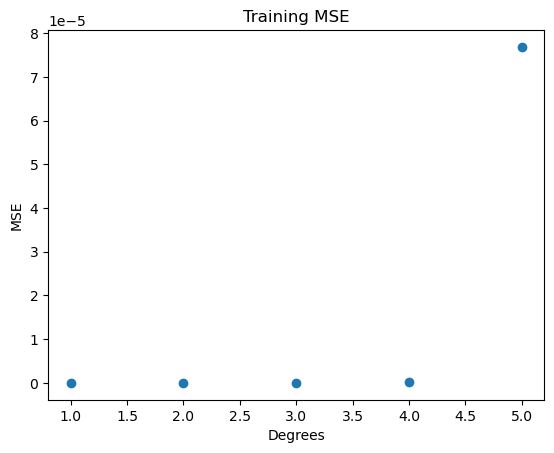

In [5]:
import matplotlib.pyplot as plt
plt.scatter(range(1,6),training_mses)
plt.xlabel("Degrees")
plt.ylabel("MSE")
plt.title("Training MSE")
plt.show()


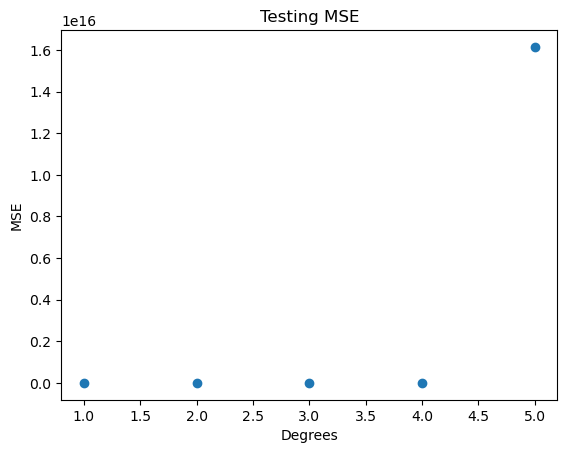

In [6]:
plt.scatter(range(1,6),testing_mses)
plt.xlabel("Degrees")
plt.ylabel("MSE")
plt.title("Testing MSE")
plt.show()

In [8]:
# Best Model So Far
min_training_index = training_mses.index(min(training_mses))
min_testing_index = testing_mses.index(min(testing_mses))
print(f'Degree of Min Training MSE: {min_training_index+1}')
print(f'Degree of Min Testing MSE: {min_testing_index+1}')

Degree of Min Training MSE: 1
Degree of Min Testing MSE: 1


In [12]:
from sklearn.linear_model import RidgeCV
import matplotlib.pyplot as plt

# RidgeCV Normalization
ridge_training_mses= []
ridge_training_r=[]
ridge_testing_mses=[]
ridge_testing_r=[]
# Dropping Degree 5 since performance was significantly worse than lower order
for degree in range(1,5):
    print(f'Degree: {degree}')
    poly = PolynomialFeatures(degree=degree, include_bias=False) 
    X_train_poly = poly.fit_transform(X_train_scaled) 
    X_test_poly = poly.transform(X_test_scaled)


    #X_val_poly = poly.transform(X_train_scaled) 
    model = RidgeCV(alphas=[0.00001,0.0001,0.001, 0.01, 0.1, 1]) 
    model.fit(X_train_poly, y_train)
    print(f"Best Alpha:{model.alpha_}")


    # Predict with the model on the training set and testing set for MSE determination
    Y_train_predict = model.predict(X_train_poly)
    Y_test_predict = model.predict(X_test_poly)

    # MSE Test
    mse_test = mean_squared_error(y_test, Y_test_predict)
    r_test = r2_score(y_test, Y_test_predict)
    
    # Add to array
    ridge_testing_mses.append(mse_test)
    ridge_testing_r.append(r_test)
    #print(f"MSE Validation: {mse_test}")
  

    #MSE TRAINING
    mse_train = mean_squared_error(y_train, Y_train_predict )
    r_train = r2_score(y_train, Y_train_predict)
    ridge_training_mses.append(mse_train)
    ridge_training_r.append(r_train)
    #print(f"MSE Testing: {mse_train}")
#MSE Results
print(f"MSE ridge Training Results: {ridge_training_mses}")
print(f"R^2 ridge Training Results: {ridge_training_r}")
print(f"MSE ridge Testing Results: {ridge_testing_mses}")
print(f"R^2 ridge Testing Results: {ridge_testing_r}")


Degree: 1
Best Alpha:1e-05
Degree: 2
Best Alpha:1e-05
Degree: 3
Best Alpha:1.0
Degree: 4
Best Alpha:0.0001
MSE ridge Training Results: [2381.498203219823, 247615876.56836388, 2865231893.366085, 5602834.0732429065]
R^2 ridge Training Results: [0.9999999999988484, 0.9999998802554126, 0.999998614402213, 0.9999999972905249]
MSE ridge Testing Results: [2406.7342668475803, 1568973.753078727, 2117215805560.3577, 24046797559969.75]
R^2 ridge Testing Results: [0.9999999999988987, 0.9999999992820436, 0.9990311701849683, 0.9889962778612632]


In [13]:
from sklearn.linear_model import LassoCV

# LassoCV Normalization
lasso_training_mses= []
lasso_training_r=[]
lasso_testing_mses=[]
lasso_testing_r=[]
# Dropping Degree 5 since performance was significantly worse than lower order
for degree in range(1,5):
    print(f'Degree: {degree}')
    poly = PolynomialFeatures(degree=degree, include_bias=False) 
    X_train_poly = poly.fit_transform(X_train_scaled) 
    X_test_poly = poly.transform(X_test_scaled)


    #X_val_poly = poly.transform(X_train_scaled) 
    model = LassoCV(alphas=[0.00001,0.0001,0.001, 0.01, 0.1, 1]) 
    model.fit(X_train_poly, y_train)
    print(f"Best Alpha:{model.alpha_}")


    # Predict with the model on the training set and testing set for MSE determination
    Y_train_predict = model.predict(X_train_poly)
    Y_test_predict = model.predict(X_test_poly)

    # MSE Test
    mse_test = mean_squared_error(y_test, Y_test_predict)
    r_test = r2_score(y_test, Y_test_predict)
    
    # Add to array
    lasso_testing_mses.append(mse_test)
    lasso_testing_r.append(r_test)
    #print(f"MSE Validation: {mse_test}")
  

    #MSE TRAINING
    mse_train = mean_squared_error(y_train, Y_train_predict )
    r_train = r2_score(y_train, Y_train_predict)
    lasso_training_mses.append(mse_train)
    lasso_training_r.append(r_train)
    #print(f"MSE Testing: {mse_train}")
#MSE Results
print(f"MSE ridge Training Results: {lasso_training_mses}")
print(f"R^2 ridge Training Results: {lasso_training_r}")
print(f"MSE ridge Testing Results: {lasso_testing_mses}")
print(f"R^2 ridge Testing Results: {lasso_testing_r}")

Degree: 1
Best Alpha:1e-05
Degree: 2


/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:1714: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:1714: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Best Alpha:1e-05
Degree: 3


/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:1714: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Best Alpha:0.1
Degree: 4


/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:1714: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Best Alpha:0.01
MSE ridge Training Results: [73700753.91780163, 2767785922.3332787, 24094068209.565308, 14352962420.399298]
R^2 ridge Training Results: [0.9999999643590448, 0.9999986615261202, 0.9999883483470682, 0.9999930590494219]
MSE ridge Testing Results: [61219132.62374315, 77143907651.72374, 19804444490844.95, 75309725665757.02]
R^2 ridge Testing Results: [0.9999999719863603, 0.9999646992443638, 0.9909375623200627, 0.9655385589909076]


Random Forest Regression

In [15]:
from sklearn.ensemble import RandomForestRegressor
forest_model = RandomForestRegressor()
forest_model.fit(X_train_scaled, y_train)

print("Default Random Forest")

# Predict with the model on the training set and testing set for MSE determination
Y_train_predict_forest = forest_model.predict(X_train_scaled)
Y_test_predict_forest = forest_model.predict(X_test_scaled)

# MSE Test
mse_test_forest = mean_squared_error(y_test, Y_test_predict_forest)
r_test_forest = r2_score(y_test, Y_test_predict_forest)
print(f'MSE TEST: {mse_test_forest}')
print(f'R^2 TEST: {r_test_forest}')

#MSE TRAINING
mse_train_forest = mean_squared_error(y_train, Y_train_predict_forest)
r_train_forest = r2_score(y_train, Y_train_predict_forest)
print(f'MSE TRAIN: {mse_train_forest}')
print(f'R^2 TRAIN: {r_train_forest}')

/opt/anaconda3/lib/python3.13/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Default Random Forest
MSE TEST: 233804079954.01663
R^2 TEST: 0.9998930121516472
MSE TRAIN: 636712051835.0245
R^2 TRAIN: 0.9996920923531482


In [16]:
print("n_estimators = 500") 
forest_model_500 = RandomForestRegressor(n_estimators=500)
forest_model_500.fit(X_train_scaled, y_train)

# Predict with the model on the training set and testing set for MSE determination
Y_train_predict_forest_500 = forest_model_500.predict(X_train_scaled)
Y_test_predict_forest_500 = forest_model_500.predict(X_test_scaled)

# MSE Test
mse_test_forest_500 = mean_squared_error(y_test, Y_test_predict_forest_500)
r_test_forest_500 = r2_score(y_test, Y_test_predict_forest_500)
print(f'MSE TEST: {mse_test_forest_500}')
print(f'R^2 TEST: {r_test_forest_500}')

#MSE TRAINING
mse_train_forest_500 = mean_squared_error(y_train, Y_train_predict_forest_500)
r_train_forest_500 = r2_score(y_train, Y_train_predict_forest_500)
print(f'MSE TRAIN: {mse_train_forest_500}')
print(f'R^2 TRAIN: {r_train_forest_500}')

n_estimators = 500


/opt/anaconda3/lib/python3.13/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


MSE TEST: 202978732662.40204
R^2 TEST: 0.9999071177120895
MSE TRAIN: 608429802874.6793
R^2 TRAIN: 0.9997057693688415
